# EDA - Explorative Data Analysis
**Author**: Erik, Smit

--- 

## Setup

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn

df = pd.read_csv("../data/raw/heart_failure_readmission_dataset.csv")
df.head()

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0


## Dataset
Below is an overview of the Kaggle dataset

In [31]:
print(f"Shape of the dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Shape of the dataset: 3000 rows, 16 columns


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               3000 non-null   int64  
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   str    
 3   bmi                      2910 non-null   float64
 4   bnp                      3000 non-null   int64  
 5   sodium                   2910 non-null   float64
 6   creatinine               2910 non-null   float64
 7   systolic_bp              3000 non-null   int64  
 8   heart_rate               3000 non-null   int64  
 9   ace_inhibitor            3000 non-null   int64  
 10  beta_blocker             3000 non-null   int64  
 11  diuretic                 3000 non-null   int64  
 12  adherence_score          3000 non-null   float64
 13  income_level             3000 non-null   str    
 14  distance_to_hospital_km  3000 non-n

In [33]:
df.describe()

,patient_id,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d
count,3000.000000,3000.000000,2910.000000,3000.000000,2910.000000,2910.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,11499.500000,65.254333,28.109038,406.308000,138.089210,1.195082,129.588667,79.364000,0.521667,0.503333,0.489000,0.699377,25.399533,0.411333
std,866.169729,14.806465,4.949035,232.273101,4.031886,0.490563,20.257120,15.269465,0.499614,0.500072,0.499962,0.172973,14.145746,0.492157
min,10000.000000,40.000000,8.800000,50.000000,124.700000,-0.590000,61.000000,19.000000,0.000000,0.000000,0.000000,0.400000,1.000000,0.000000
25%,10749.750000,52.000000,24.800000,225.000000,135.300000,0.870000,116.000000,69.000000,0.000000,0.000000,0.000000,0.550000,12.800000,0.000000
50%,11499.500000,65.000000,28.100000,392.000000,138.100000,1.200000,130.000000,79.000000,1.000000,1.000000,0.000000,0.700000,25.450000,0.000000
75%,12249.250000,78.000000,31.500000,569.000000,140.800000,1.520000,143.000000,90.000000,1.000000,1.000000,1.000000,0.850000,37.525000,1.000000
max,12999.000000,90.000000,44.900000,1381.000000,151.600000,2.940000,196.000000,147.000000,1.000000,1.000000,1.000000,1.000000,50.000000,1.000000


In total, there are **15 features**, most of which are integers or floats. The two features that stand out in terms of datatype is **gender** and **income_level**, which are strings can take the follwoing values:
- **gender** - "Male", "Female".
- **income_level** - "Low", "Medium", "High".

Furthermore, there appears to be some missing values for the features: **sodium, creatinine, bmi**

## Target Variable Analysis

In [34]:
df["readmitted_30d"].value_counts(normalize=True)

readmitted_30d
0    0.588667
1    0.411333
Name: proportion, dtype: float64

<Axes: xlabel='readmitted_30d', ylabel='count'>

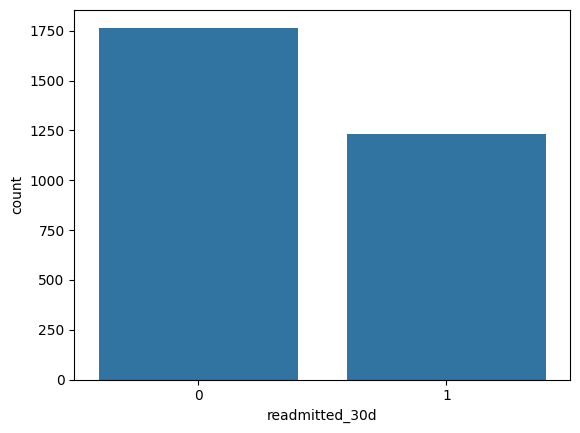

In [35]:
sns.countplot(x="readmitted_30d", data=df)

The distribution of readmitted patients appears to be slightly shifted. Overall, we can see that
- % Readmitted $\approx 41.1 \%$
- % Not Readmitted $\approx 58.9 \%$

## Feature Analysis
I've split up the feature analysis into three main parts: clinical features, treatment factors, and social determinants.

### Clinical Features
The clinical features consists of:
- Age
- Gender
- BMI
- BNP
- Sodium
- Creatinine
- Systolic BP
- Heart Rate

I will outline/investigate these features below

#### Age


In [36]:
df.groupby("readmitted_30d")["age"].mean()

readmitted_30d
0    64.121744
1    66.875203
Name: age, dtype: float64

Text(0.5, 1.0, 'Age distribution by readmission status')

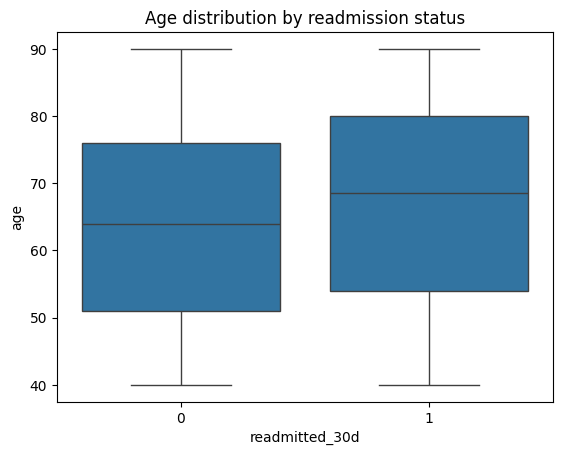

In [37]:
sns.boxplot(x="readmitted_30d", y="age", data=df).set_title("Age distribution by readmission status")

The means and medians of the group of readmitted and the group of non-readmitted patients seems to be marginally the same. This suggests that age appears to have a small impact on 30-day readmission.

#### Gender

Text(0.5, 1.0, 'Gender distribution by readmission status')

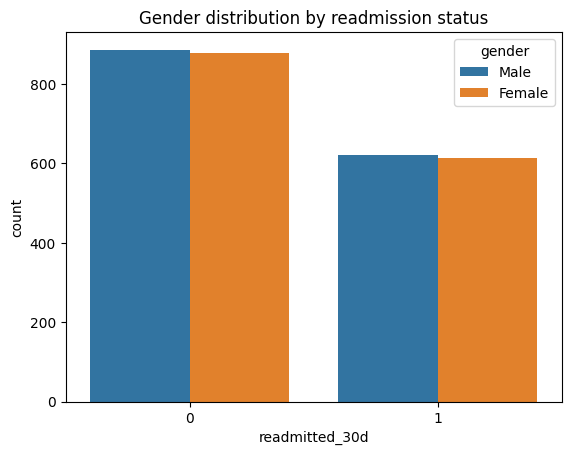

In [67]:
sns.countplot(x="readmitted_30d", hue="gender",data=df).set_title("Gender distribution by readmission status")

Overall, the dataset appears to be fairly balanced w.r.t. gender. Furthermore, gender appears to have no strong association with 30-day readmission

#### BMI (Body Mass Index)

In [38]:
df.groupby("readmitted_30d")["bmi"].mean()

readmitted_30d
0    27.992119
1    28.276358
Name: bmi, dtype: float64

Text(0.5, 1.0, 'BMI distribution by readmission status')

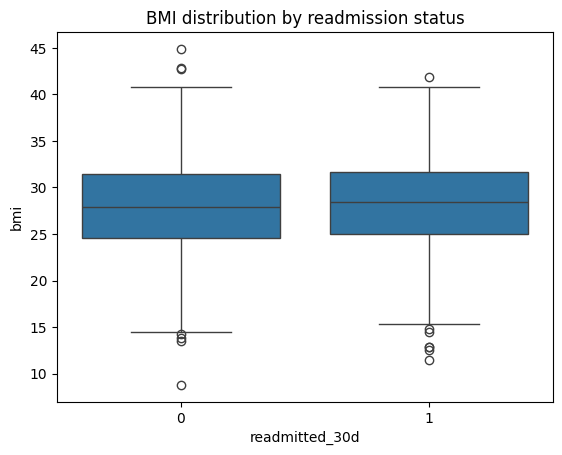

In [39]:
sns.boxplot(x="readmitted_30d", y="bmi", data=df).set_title("BMI distribution by readmission status")

The readmitted and non-readmitted groups seems to have similar BMI distributions, suggesting that this feature is not particuralry associated with 30-day readmission.

#### BNP (B-type natriuretic peptide)


In [40]:
df.groupby("readmitted_30d")["bnp"].mean()

readmitted_30d
0    374.988109
1    451.130470
Name: bnp, dtype: float64

Text(0.5, 1.0, 'BNP distribution by readmission status')

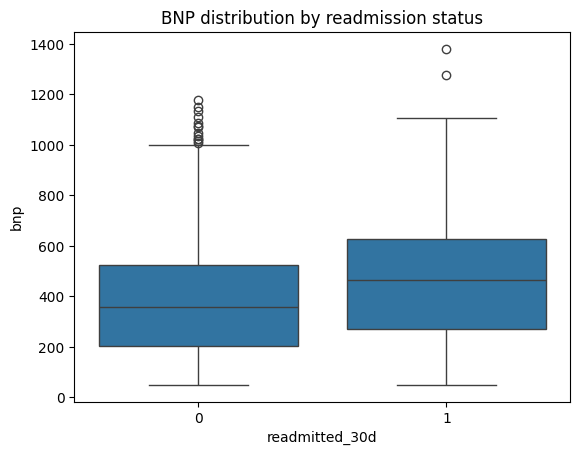

In [41]:
sns.boxplot(x="readmitted_30d", y="bnp", data=df).set_title("BNP distribution by readmission status")

Patients who were readmitted show higher median BNP levels compared to those who were not. Furthermore, the distribution of BNP is shifted upward in the readmitted group, indicating generally higher values.There is also greater variability in BNP among readmitted patients.

These findings suggest that higher BNP levels (indicative of more severe heart failure) are associated with increased risk of 30-day readmission.

#### Sodium

In [42]:
df.groupby("readmitted_30d")["sodium"].mean()

readmitted_30d
0    138.262412
1    137.843095
Name: sodium, dtype: float64

Text(0.5, 1.0, 'Sodium distribution by readmission status')

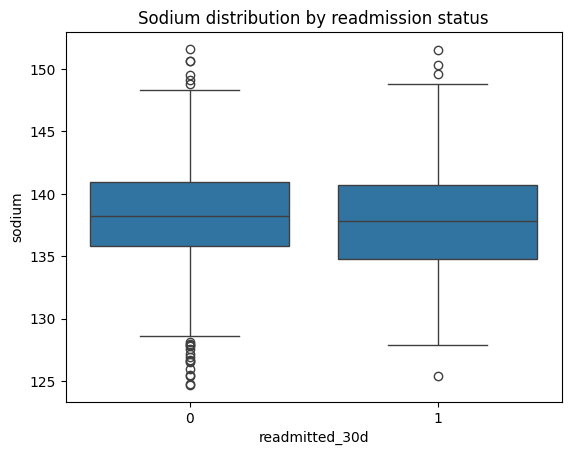

In [43]:
sns.boxplot(x="readmitted_30d", y="sodium", data=df).set_title("Sodium distribution by readmission status")

Sodium shows only a weak association with 30-day readmission, with substantial overlap between the two groups.

#### Creatinine

In [44]:
df.groupby("readmitted_30d")["creatinine"].mean()

readmitted_30d
0    1.177998
1    1.219188
Name: creatinine, dtype: float64

Text(0.5, 1.0, 'Creatinine distribution by readmission status')

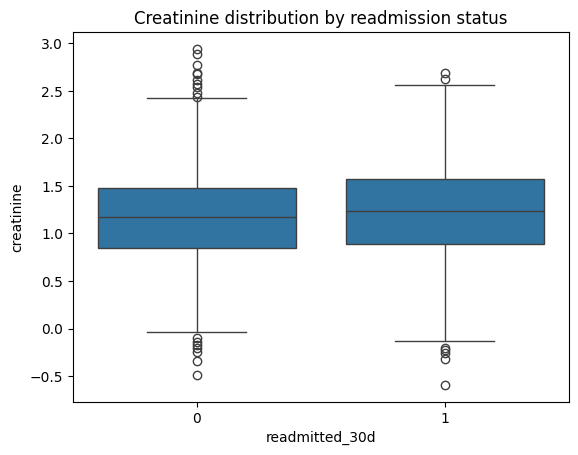

In [45]:
sns.boxplot(x="readmitted_30d", y="creatinine", data=df).set_title("Creatinine distribution by readmission status")

Creatinine shows only a weak association with 30-day readmission, with substantial overlap between the two groups.

#### Systolic BP (Systolic Blood Pressure)

In [46]:
df.groupby("readmitted_30d")["systolic_bp"].mean()

readmitted_30d
0    128.994904
1    130.438412
Name: systolic_bp, dtype: float64

Text(0.5, 1.0, 'Systolic BP distribution by readmission status')

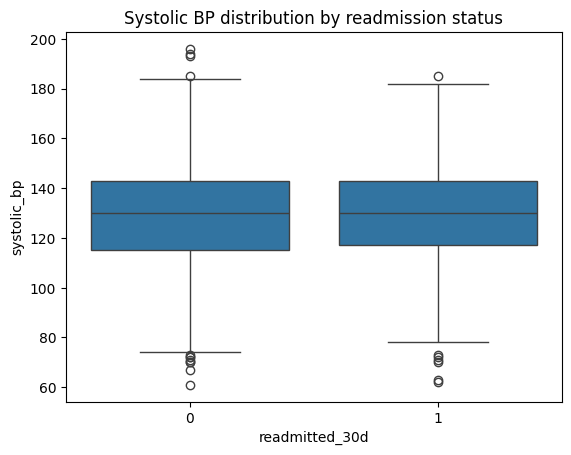

In [47]:
sns.boxplot(x="readmitted_30d", y="systolic_bp", data=df).set_title("Systolic BP distribution by readmission status")

Systolic blood pressure shows no clear difference between readmitted and non-readmitted patients, with nearly identical distributions and substantial overlap between the two groups.

#### Heart Rate

In [48]:
df.groupby("readmitted_30d")["heart_rate"].mean()

readmitted_30d
0    79.523216
1    79.136143
Name: heart_rate, dtype: float64

Text(0.5, 1.0, 'Heart Rate distribution by readmission status')

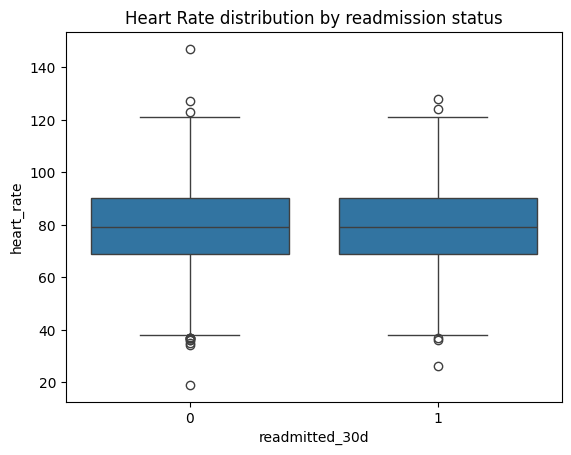

In [49]:
sns.boxplot(x="readmitted_30d", y="heart_rate", data=df).set_title("Heart Rate distribution by readmission status")

Similar to many other clinical features, heart rate show no no clear difference between readmitted and non-readmitted patients, with nearly identical distributions and substantial overlap between the two groups.

### Treatment Features
The treatment features consist of:
- Ace Inhibitor
- Beta Blocker
- Diuretic
- Adherence Score

Below I've outlined/invesigated these features.

#### Ace Inhibitor

In [50]:
df.groupby("readmitted_30d")["ace_inhibitor"].mean()

readmitted_30d
0    0.560589
1    0.465964
Name: ace_inhibitor, dtype: float64

<Axes: title={'center': 'ACE Inhibitor usage by readmission status'}, xlabel='readmitted_30d'>

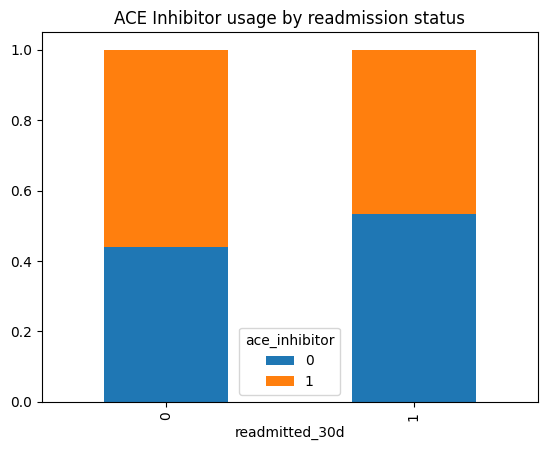

In [53]:
pd.crosstab(df["readmitted_30d"], df["ace_inhibitor"], normalize="index").plot(kind="bar", stacked=True, title="ACE Inhibitor usage by readmission status")

Patients who were not readmitted had a higher proportion of ACE inhibitor use compared to those who were readmitted. Conversely, readmitted patients were more likely to not be on ACE inhibitors.

This suggests that ACE inhibitor use may be associated with a reduced risk of 30-day readmission, although further analysis is needed to confirm this relationship.

### Beta Blocker

In [54]:
df.groupby("readmitted_30d")["beta_blocker"].mean()

readmitted_30d
0    0.539071
1    0.452188
Name: beta_blocker, dtype: float64

<Axes: title={'center': 'Beta Blocker usage by readmission status'}, xlabel='readmitted_30d'>

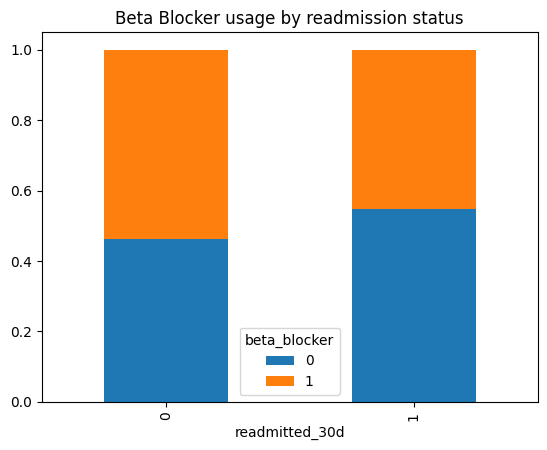

In [56]:
pd.crosstab(df["readmitted_30d"], df["beta_blocker"], normalize="index").plot(kind="bar", stacked=True, title="Beta Blocker usage by readmission status")

Patients who were not readmitted had a higher proportion of beta blockers use compared to those who were readmitted. Conversely, readmitted patients were more likely to not be beta blockers.

This suggests that the use of beta blockers may be associated with a reduced risk of 30-day readmission, although further analysis is needed to confirm this relationship.

#### Diuretic

In [61]:
df.groupby("readmitted_30d")["diuretic"].mean()

readmitted_30d
0    0.482446
1    0.498379
Name: diuretic, dtype: float64

<Axes: title={'center': 'Diuretic usage by readmission status'}, xlabel='readmitted_30d'>

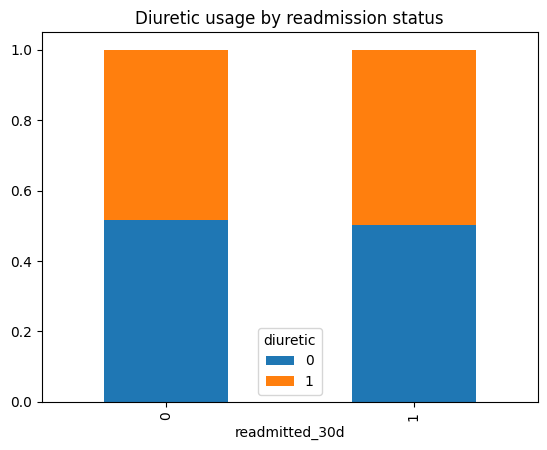

In [60]:
pd.crosstab(df["readmitted_30d"], df["diuretic"], normalize="index").plot(kind="bar", stacked=True, title="Diuretic usage by readmission status")

Diuretic use shows little to no association with 30-day readmission, as the proportions are nearly identical between groups.

#### Adherence Score

In [62]:
df.groupby("readmitted_30d")["adherence_score"].mean()

readmitted_30d
0    0.727384
1    0.659295
Name: adherence_score, dtype: float64

Text(0.5, 1.0, 'Adherence Score distribution by readmission status')

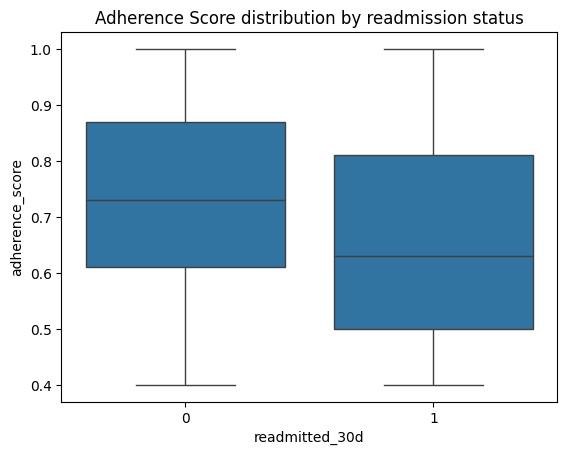

In [63]:
sns.boxplot(x="readmitted_30d", y="adherence_score", data=df).set_title("Adherence Score distribution by readmission status")

Lower adherence score seems to be associated with 30-day readmission.

### SDoH Features
The SDoH features are:
- Income level
- Distance to Hospital

Below I've outlined/investigated these features.

#### Income Level